# Board2Notes — 2. Model İçin Multi-Head Sentetik Dataset Üretimi

Bu FIXED notebook, Roboflow'daki **COCO Segmentation** formatındaki boş tahta veri setini indirir, `board` maskelerinden temiz tahta crop/background çıkarır ve 2. modelde kullanmak üzere sentetik eğitim seti üretir.

Üretilen dataset formatı:

```text
Board2Notes/generated_multihead_dataset/
  train/
    input/             # bozulmuş tahta görüntüsü
    target_restored/   # temiz yazılı tahta
    target_ocr/        # OCR için yazısı belirginleştirilmiş hedef
    text_mask/         # yazı maskesi
    text_layer/        # şeffaf arka planlı yazı katmanı, RGBA PNG
    text_on_white/     # boş beyaz sayfaya yapıştırılmış yazılar
  val/
  test/
```

Bu notebook sadece **2. model** için dataset üretir. Tahta segmentasyon modeli eğitmez.

> Önemli: Roboflow API anahtarını notebook içinde kalıcı olarak yazmak yerine çalıştırırken gizli şekilde girmen önerilir.

In [ ]:
# ============================================================
# 0) Ortam kontrolü ve güvenli kurulum
# ============================================================
# ÖNEMLİ:
# Bu hücre Colab'ın pandas / pillow / opencv paketlerini upgrade etmez.
# Önceki sürümde -U kullanımı Pillow/Pandas uyumsuzluğu oluşturabiliyordu.

import os, sys, platform, subprocess, json, random, math, shutil, zipfile, glob, time
from pathlib import Path

print("Python:", platform.python_version())

# Sadece eksik olabilecek iki paketi kuruyoruz.
# Colab'daki pillow/pandas/opencv/matplotlib sürümlerine dokunmuyoruz.
!pip -q install roboflow pycocotools --upgrade-strategy only-if-needed

import cv2
import numpy as np
import pandas as pd

try:
    from PIL import Image, ImageDraw, ImageFont, ImageFilter
except ImportError as e:
    raise RuntimeError(
        "Pillow ortamı bozulmuş görünüyor. Muhtemel sebep: önceki hücrede pillow/pandas upgrade edildi.\n"
        "Çözüm: Colab menüsünden Runtime > Restart session yap, sonra bu FIXED notebook'u en baştan çalıştır.\n"
        "Pillow'u tekrar -U ile upgrade etme."
    ) from e

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

try:
    import torch
    print("Torch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("Torch kontrolü atlandı:", e)

print("Pandas:", pd.__version__)
print("Pillow:", Image.__version__)
print("OpenCV:", cv2.__version__)
print("OK")

Python: 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 149.6 MB/s eta 0:00:00
Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
Pandas: 2.2.2
Pillow: 11.3.0
OpenCV: 4.10.0
OK


In [ ]:
# ============================================================
# 1) Drive bağla ve ana konfigürasyon
# ============================================================
from google.colab import drive

drive.mount('/content/drive')

class CFG:
    # ---- Roboflow dataset bilgileri ----
    RF_WORKSPACE = "samets-workspace-4soa9"
    RF_PROJECT   = "b2n_2"
    RF_VERSION   = 1
    RF_FORMAT    = "coco-segmentation"
    BOARD_CLASS_NAME = "board"

    # ---- Drive yolları ----
    DRIVE_ROOT = Path("/content/drive/MyDrive/Board2Notes")
    HANDWRITING_DIR = DRIVE_ROOT / "handwriting"
    HANDWRITING_ZIP = DRIVE_ROOT / "handwriting.zip"

    # Roboflow indirme ve ara çıktı
    WORK_DIR = Path("/content/b2n_dataset_generation")
    RF_DIR = WORK_DIR / "roboflow_b2n2"
    BOARD_CROPS_DIR = DRIVE_ROOT / "board_crops_empty"

    # Final dataset
    OUT_DATASET_DIR = DRIVE_ROOT / "generated_multihead_dataset"
    OUT_ZIP = DRIVE_ROOT / "generated_multihead_dataset.zip"

    # Board crop boyutu. 16:9 akıllı tahta/beyaz tahta için dengeli.
    BOARD_W = 1024
    BOARD_H = 576

    # Dataset üretim miktarları
    SEED = 42
    SPLIT = (0.80, 0.10, 0.10)   # board bazlı split: train / val / test
    PAIRS_PER_BOARD_TRAIN = 40
    PAIRS_PER_BOARD_VAL   = 10
    PAIRS_PER_BOARD_TEST  = 10

    # Eğer ilk hızlı deneme yapmak istersen True yap.
    SMOKE_MODE = False
    SMOKE_MAX_BOARDS = 12
    SMOKE_PAIRS_PER_BOARD_TRAIN = 6
    SMOKE_PAIRS_PER_BOARD_VAL = 2
    SMOKE_PAIRS_PER_BOARD_TEST = 2

    # Gerçek eğitim için font fallback önerilmez. El yazısı PNG azsa hata versin.
    ALLOW_FONT_FALLBACK_FOR_DEBUG = False
    MIN_HANDWRITING_ITEMS = 25

    # Yazı yerleşimi
    DENSITY_PROBS = {"sparse": 0.25, "medium": 0.50, "dense": 0.25}

    # Bozulma zorluğu dağılımı
    DIFFICULTY_PROBS = {"easy": 0.40, "medium": 0.45, "hard": 0.15}

    # Çıktıyı yeniden oluştururken eski klasörü silmek istiyorsan True
    RESET_OUTPUT_DATASET = True
    RESET_BOARD_CROPS = False

for p in [CFG.DRIVE_ROOT, CFG.HANDWRITING_DIR, CFG.WORK_DIR, CFG.RF_DIR, CFG.BOARD_CROPS_DIR, CFG.OUT_DATASET_DIR]:
    p.mkdir(parents=True, exist_ok=True)

random.seed(CFG.SEED)
np.random.seed(CFG.SEED)

print("Drive root:", CFG.DRIVE_ROOT)
print("Handwriting dir:", CFG.HANDWRITING_DIR)
print("Output dataset:", CFG.OUT_DATASET_DIR)
print("Board crop size:", CFG.BOARD_W, "x", CFG.BOARD_H)

Mounted at /content/drive
Drive root: /content/drive/MyDrive/Board2Notes
Handwriting dir: /content/drive/MyDrive/Board2Notes/handwriting
Output dataset: /content/drive/MyDrive/Board2Notes/generated_multihead_dataset
Board crop size: 1024 x 576


Eski crop klasörü temizleniyor: /content/drive/MyDrive/Board2Notes/board_backgrounds_v2
Board crop çıktı klasörü: /content/drive/MyDrive/Board2Notes/board_backgrounds_v2
Kullanılacak COCO annotation dosyaları:
 - /content/b2n_dataset_generation/roboflow_b2n2_v2/train/_annotations.coco.json

Categories: [{'id': 0, 'name': 'B2N-2', 'supercategory': 'none'}, {'id': 1, 'name': 'board', 'supercategory': 'B2N-2'}]
Board category ids: {1}
COCO images: 154 | board annotation image sayısı: 154


crop train:   0%|          | 0/154 [00:00<?, ?it/s]


Board crop çıkarma tamamlandı.
Kaydedilen crop sayısı: 123
Atlanan örnek sayısı: 31
Metadata: /content/drive/MyDrive/Board2Notes/board_backgrounds_v2/board_crop_metadata.json
Crop klasörü: /content/drive/MyDrive/Board2Notes/board_backgrounds_v2

İlk 10 atlanan:
 - ('WhatsApp-Image-2026-05-12-at-19-54-37-2-_jpeg.rf.a0511f1f85ca84aab369c3ba229b3d3b.jpg', {'reason': 'small_crop', 'out_w': 455, 'out_h': 160})
 - ('WhatsApp-Image-2026-05-12-at-19-54-04-1-_jpeg.rf.f5341e00e0737c168ac744024765a8b3.jpg', {'reason': 'small_crop', 'out_w': 411, 'out_h': 308})
 - ('WhatsApp-Image-2026-05-12-at-19-54-05_jpeg.rf.36e3b285fd0ddc17bcd6bfa008696610.jpg', {'reason': 'small_crop', 'out_w': 402, 'out_h': 288})
 - ('WhatsApp-Image-2026-05-12-at-19-54-06_jpeg.rf.7a61662c1818d5b21bd482d830db0070.jpg', {'reason': 'small_crop', 'out_w': 643, 'out_h': 217})
 - ('WhatsApp-Image-2026-05-12-at-19-54-46_jpeg.rf.bce3f383ed231ef324c9bd52a71528a5.jpg', {'reason': 'small_crop', 'out_w': 564, 'out_h': 274})
 - ('WhatsA

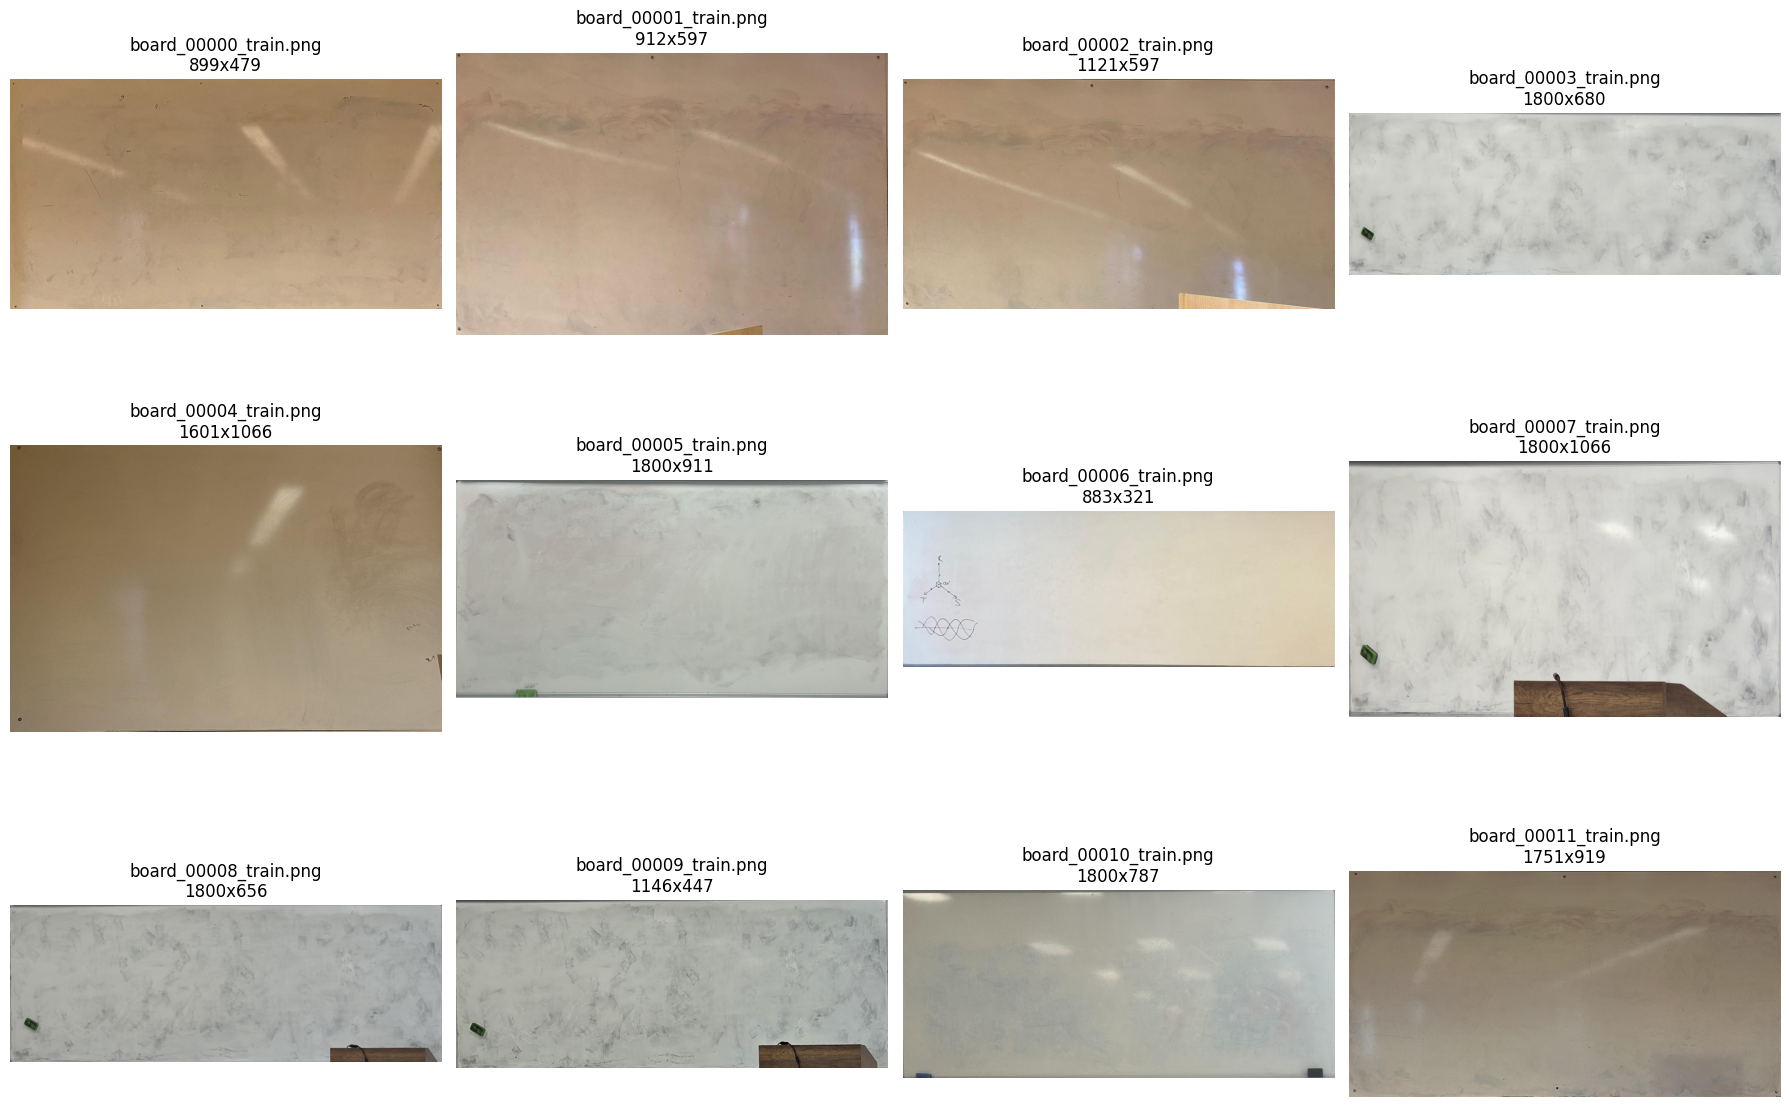

BOARD_BACKGROUNDS hazır: 123


In [ ]:
# ============================================================
# Board crop/background çıkarma + Drive'a kaydetme + preview
# Roboflow v2 COCO Segmentation çıktısı için düzeltilmiş blok
# ============================================================

from pathlib import Path
import json, os, math, shutil
import numpy as np
import cv2
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Çıktı klasörleri
# ------------------------------------------------------------

CFG.BOARD_CROP_DIR = Path("/content/drive/MyDrive/Board2Notes/board_backgrounds_v2")
CFG.BOARD_CROP_DIR.mkdir(parents=True, exist_ok=True)

# İstersen eski crop'ları temizle
CLEAR_OLD_CROPS = True

if CLEAR_OLD_CROPS and CFG.BOARD_CROP_DIR.exists():
    print("Eski crop klasörü temizleniyor:", CFG.BOARD_CROP_DIR)
    shutil.rmtree(CFG.BOARD_CROP_DIR)

CFG.BOARD_CROP_DIR.mkdir(parents=True, exist_ok=True)

print("Board crop çıktı klasörü:", CFG.BOARD_CROP_DIR)

# ------------------------------------------------------------
# Ayarlar
# ------------------------------------------------------------

BOARD_CLASS_NAME = "board"

# Çok küçük/bozuk maskeleri elemek için
MIN_MASK_AREA_RATIO = 0.02      # görüntünün en az %2'si board olmalı
MIN_CROP_SIDE = 320             # çıkarılan crop minimum kenar
MAX_CROP_LONG_SIDE = 1800       # yüksek kalite ama aşırı büyük olmasın
JPEG_QUALITY = 95

# Perspective crop için board'un hedef boyutunu gerçek kenar uzunluklarından hesaplayacağız.
# Çok devasa crop olmasın diye uzun kenarı MAX_CROP_LONG_SIDE ile sınırlıyoruz.

# ------------------------------------------------------------
# Yardımcı fonksiyonlar
# ------------------------------------------------------------

def order_quad_points(pts):
    """
    4 noktayı [top-left, top-right, bottom-right, bottom-left] sırasına koyar.
    """
    pts = np.asarray(pts, dtype=np.float32)
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1).reshape(-1)

    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(d)]
    bl = pts[np.argmax(d)]

    return np.array([tl, tr, br, bl], dtype=np.float32)


def polygon_to_mask(segmentation, h, w):
    """
    COCO polygon segmentation -> binary mask
    Roboflow COCO Segmentation genelde list polygon verir.
    """
    mask = np.zeros((h, w), dtype=np.uint8)

    if segmentation is None:
        return mask

    # Polygon list formatı: [[x1,y1,x2,y2,...], [...]]
    if isinstance(segmentation, list):
        for poly in segmentation:
            if not isinstance(poly, list) or len(poly) < 6:
                continue
            pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
            pts = np.round(pts).astype(np.int32)
            cv2.fillPoly(mask, [pts], 255)
        return mask

    # RLE fallback
    if isinstance(segmentation, dict):
        try:
            from pycocotools import mask as mask_utils
            rle_mask = mask_utils.decode(segmentation)
            if rle_mask.ndim == 3:
                rle_mask = rle_mask[..., 0]
            mask = (rle_mask > 0).astype(np.uint8) * 255
            return mask
        except Exception as e:
            print("RLE decode başarısız:", e)
            return mask

    return mask


def find_best_board_quad(mask):
    """
    Maskeden board için 4 köşe bulmaya çalışır.
    Önce contour + approxPolyDP dener.
    Olmazsa minAreaRect kullanır.
    """
    m = (mask > 0).astype(np.uint8)

    # Temizlik
    kernel = np.ones((7, 7), np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel, iterations=2)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, kernel, iterations=1)

    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not cnts:
        return None, 0.0

    c = max(cnts, key=cv2.contourArea)
    area = float(cv2.contourArea(c))

    if area <= 10:
        return None, area

    peri = cv2.arcLength(c, True)

    # Farklı epsilon değerleriyle 4 köşe yakalamaya çalış
    quad = None
    for eps in [0.01, 0.015, 0.02, 0.03, 0.04, 0.06]:
        approx = cv2.approxPolyDP(c, eps * peri, True)
        if len(approx) == 4:
            quad = approx.reshape(4, 2).astype(np.float32)
            break

    # Olmazsa minAreaRect
    if quad is None:
        rect = cv2.minAreaRect(c)
        quad = cv2.boxPoints(rect).astype(np.float32)

    quad = order_quad_points(quad)
    return quad, area


def warp_board_rgb(img_rgb, mask):
    """
    Board maskesine göre perspective crop çıkarır.
    """
    h, w = img_rgb.shape[:2]
    quad, area = find_best_board_quad(mask)

    if quad is None:
        return None, {"reason": "no_quad", "area": area}

    area_ratio = area / float(h * w)
    if area_ratio < MIN_MASK_AREA_RATIO:
        return None, {"reason": "small_area", "area_ratio": area_ratio}

    tl, tr, br, bl = quad

    width_top = np.linalg.norm(tr - tl)
    width_bottom = np.linalg.norm(br - bl)
    height_left = np.linalg.norm(bl - tl)
    height_right = np.linalg.norm(br - tr)

    out_w = int(round(max(width_top, width_bottom)))
    out_h = int(round(max(height_left, height_right)))

    if out_w < MIN_CROP_SIDE or out_h < MIN_CROP_SIDE:
        return None, {"reason": "small_crop", "out_w": out_w, "out_h": out_h}

    # Çok büyük crop'ları kontrollü küçült
    long_side = max(out_w, out_h)
    if long_side > MAX_CROP_LONG_SIDE:
        scale = MAX_CROP_LONG_SIDE / long_side
        out_w = int(round(out_w * scale))
        out_h = int(round(out_h * scale))

    out_w = max(MIN_CROP_SIDE, out_w)
    out_h = max(MIN_CROP_SIDE, out_h)

    dst = np.array([
        [0, 0],
        [out_w - 1, 0],
        [out_w - 1, out_h - 1],
        [0, out_h - 1],
    ], dtype=np.float32)

    M = cv2.getPerspectiveTransform(quad, dst)

    warped = cv2.warpPerspective(
        img_rgb,
        M,
        (out_w, out_h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    info = {
        "area_ratio": area_ratio,
        "out_w": out_w,
        "out_h": out_h,
        "quad": quad.tolist(),
    }

    return warped, info


def resolve_image_path(base_dir, file_name, rf_root=None):
    """
    COCO image file_name bazen direkt dosya adı, bazen alt klasörlü gelebiliyor.
    Önce annotation klasörüne göre dener, olmazsa rf_root altında arar.
    """
    p1 = Path(base_dir) / file_name
    if p1.exists():
        return p1

    if rf_root is not None:
        matches = list(Path(rf_root).rglob(Path(file_name).name))
        if matches:
            return matches[0]

    return None


# ------------------------------------------------------------
# Annotation dosyalarını kontrol
# ------------------------------------------------------------

assert hasattr(CFG, "ANN_FILES"), "Önce Roboflow v2 indirme bloğunu çalıştırmalısın. CFG.ANN_FILES yok."
ann_files = [Path(p) for p in CFG.ANN_FILES]

print("Kullanılacak COCO annotation dosyaları:")
for p in ann_files:
    print(" -", p)

# ------------------------------------------------------------
# Board crop çıkar
# ------------------------------------------------------------

all_infos = []
saved = 0
skipped = []

for ann_path in ann_files:
    ann_path = Path(ann_path)
    base_dir = ann_path.parent

    with open(ann_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    cats = coco.get("categories", [])
    print("\nCategories:", cats)

    # board class id bul
    board_cat_ids = []
    for c in cats:
        name = str(c.get("name", "")).lower().strip()
        if name == BOARD_CLASS_NAME.lower():
            board_cat_ids.append(c["id"])

    # Eğer class adı farklıysa fallback: tek class varsa onu kullan
    if not board_cat_ids:
        if len(cats) == 1:
            board_cat_ids = [cats[0]["id"]]
            print(f"UYARI: '{BOARD_CLASS_NAME}' class bulunamadı. Tek class kullanılıyor:", cats[0])
        else:
            raise RuntimeError(
                f"'{BOARD_CLASS_NAME}' class bulunamadı. Categories: {cats}. "
                "Roboflow class adını board yaptığından emin ol."
            )

    board_cat_ids = set(board_cat_ids)
    print("Board category ids:", board_cat_ids)

    # image_id -> image info
    images = {im["id"]: im for im in coco.get("images", [])}

    # image_id -> anns
    anns_by_img = {}
    for a in coco.get("annotations", []):
        if a.get("category_id") in board_cat_ids:
            anns_by_img.setdefault(a["image_id"], []).append(a)

    print("COCO images:", len(images), "| board annotation image sayısı:", len(anns_by_img))

    for img_id, anns in tqdm(list(anns_by_img.items()), desc=f"crop {ann_path.parent.name}"):
        im_info = images.get(img_id)
        if im_info is None:
            skipped.append((str(img_id), "image_info_missing"))
            continue

        file_name = im_info.get("file_name")
        img_path = resolve_image_path(base_dir, file_name, rf_root=CFG.RF_DIR)

        if img_path is None or not Path(img_path).exists():
            skipped.append((file_name, "image_file_missing"))
            continue

        # Görüntüyü oku
        bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if bgr is None:
            skipped.append((file_name, "cv2_read_failed"))
            continue

        img_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]

        # Aynı görselde birden fazla board annotation varsa en büyük maskeyi seç
        best_mask = None
        best_area = -1

        for a in anns:
            mask = polygon_to_mask(a.get("segmentation"), h, w)
            area = int((mask > 0).sum())

            if area > best_area:
                best_area = area
                best_mask = mask

        if best_mask is None or best_area <= 0:
            skipped.append((file_name, "empty_mask"))
            continue

        crop, info = warp_board_rgb(img_rgb, best_mask)

        if crop is None:
            skipped.append((file_name, info))
            continue

        split_name = ann_path.parent.name
        out_name = f"board_{saved:05d}_{split_name}.png"
        out_path = CFG.BOARD_CROP_DIR / out_name

        # RGB -> BGR save
        cv2.imwrite(
            str(out_path),
            cv2.cvtColor(crop, cv2.COLOR_RGB2BGR),
            [cv2.IMWRITE_PNG_COMPRESSION, 3]
        )

        info.update({
            "out_file": out_name,
            "source_file": str(img_path),
            "split": split_name,
        })

        all_infos.append(info)
        saved += 1

# Metadata kaydet
meta_path = CFG.BOARD_CROP_DIR / "board_crop_metadata.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(all_infos, f, ensure_ascii=False, indent=2)

print("\nBoard crop çıkarma tamamlandı.")
print("Kaydedilen crop sayısı:", saved)
print("Atlanan örnek sayısı:", len(skipped))
print("Metadata:", meta_path)
print("Crop klasörü:", CFG.BOARD_CROP_DIR)

if skipped[:10]:
    print("\nİlk 10 atlanan:")
    for s in skipped[:10]:
        print(" -", s)

assert saved > 0, "Hiç board crop çıkarılamadı. Annotation/mask kontrol edilmeli."

# ------------------------------------------------------------
# Crop boyut kontrolü
# ------------------------------------------------------------

crop_paths = sorted(CFG.BOARD_CROP_DIR.glob("*.png"))

sizes = []
for p in crop_paths:
    im = Image.open(p)
    sizes.append((p.name, im.size[0], im.size[1]))
    im.close()

ws = [s[1] for s in sizes]
hs = [s[2] for s in sizes]

print("\nCrop görüntü sayısı:", len(sizes))
print("Crop width  min/mean/max:", min(ws), int(np.mean(ws)), max(ws))
print("Crop height min/mean/max:", min(hs), int(np.mean(hs)), max(hs))

print("\nİlk 10 crop boyutu:")
for name, w, h in sizes[:10]:
    print(f" - {name}: {w}x{h}")

# ------------------------------------------------------------
# Preview göster
# ------------------------------------------------------------

n_show = min(12, len(crop_paths))
sample_paths = crop_paths[:n_show]

cols = 4
rows = math.ceil(n_show / cols)

plt.figure(figsize=(18, 4.2 * rows))

for i, p in enumerate(sample_paths):
    im = Image.open(p).convert("RGB")
    plt.subplot(rows, cols, i + 1)
    plt.imshow(im)
    plt.title(f"{p.name}\n{im.size[0]}x{im.size[1]}")
    plt.axis("off")
    im.close()

plt.tight_layout()
plt.show()

# Sonraki bloklar için
BOARD_BACKGROUNDS = crop_paths

print("BOARD_BACKGROUNDS hazır:", len(BOARD_BACKGROUNDS))

Handwriting klasörü: /content/drive/MyDrive/Board2Notes/handwriting
/content/drive/MyDrive/Board2Notes/handwriting boş. Hugging Face'ten Teklia/IAM-line indirilecek.
Bu işlem ilk kez çalışırken biraz sürebilir.



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


README.md:   0%|          | 0.00/2.14k [00:00<?, ?B/s]

IAM-line indiriliyor:   0%|          | 0/3000 [00:00<?, ?it/s]

İndirilen handwriting satır sayısı: 3000
Metadata: /content/drive/MyDrive/Board2Notes/handwriting/iam_line_metadata.json


handwriting parçaları yükleniyor:   0%|          | 0/3000 [00:00<?, ?it/s]

Yüklenen handwriting parça sayısı: 3000


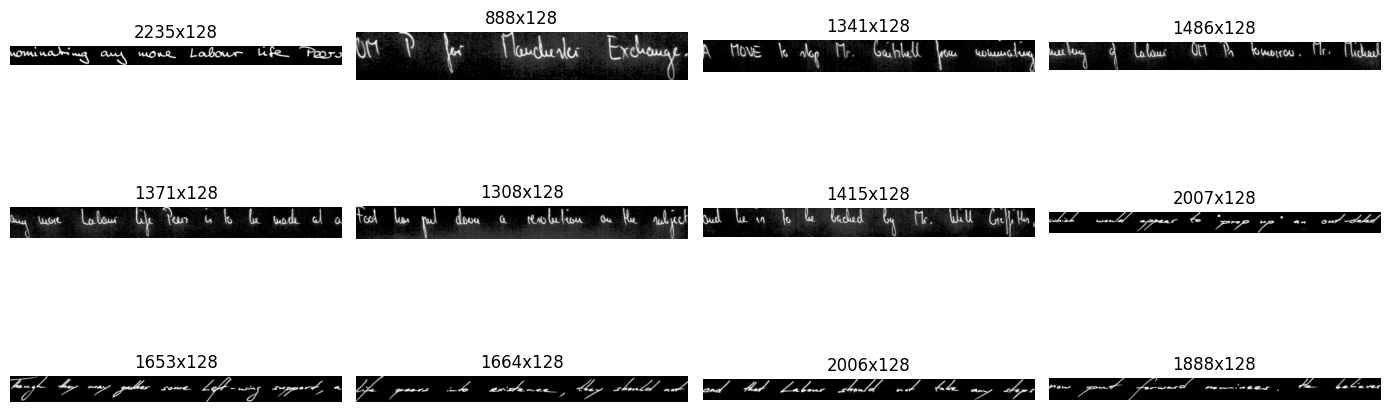

Handwriting dataset hazır.


In [ ]:
# ============================================================
# Handwriting dataset otomatik indir + parça yükle
# Kaynak: Hugging Face Teklia/IAM-line
# Bu blok eski "handwriting yükleme" bloğunun yerine geçer.
# ============================================================

from pathlib import Path
import os, shutil, random, json, math
import numpy as np
import cv2
from PIL import Image, ImageOps
from tqdm.auto import tqdm

# ------------------------------------------------------------
# 0) Ayarlar
# ------------------------------------------------------------

# Drive tarafında kalıcı saklanacak handwriting klasörü
CFG.HANDWRITING_DIR = Path("/content/drive/MyDrive/Board2Notes/handwriting")
CFG.HANDWRITING_DIR.mkdir(parents=True, exist_ok=True)

# Hugging Face'ten indirilecek maksimum satır sayısı
# İlk deneme için 3000 iyi. İstersen 6000 yapabiliriz.
CFG.HF_HANDWRITING_DATASET = "Teklia/IAM-line"
CFG.MAX_HF_HANDWRITING_LINES = 3000

# Çok kısa/çok uzun satırları elemek için sınırlar
CFG.MIN_HW_WIDTH = 80
CFG.MIN_HW_HEIGHT = 20
CFG.MAX_HW_ASPECT = 18.0

# Gerçek eğitim için font fallback kapalı kalabilir
CFG.ALLOW_FONT_FALLBACK_FOR_DEBUG = False

print("Handwriting klasörü:", CFG.HANDWRITING_DIR)

# ------------------------------------------------------------
# 1) Hugging Face datasets kurulumu
# ------------------------------------------------------------

try:
    import datasets
except Exception:
    print("datasets paketi kuruluyor...")
    !pip -q install "datasets<4" "huggingface_hub"
    import datasets

from datasets import load_dataset

# ------------------------------------------------------------
# 2) Eğer handwriting klasörü boşsa IAM-line indir
# ------------------------------------------------------------

img_exts = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}
existing_imgs = [p for p in CFG.HANDWRITING_DIR.rglob("*") if p.suffix.lower() in img_exts]

if len(existing_imgs) == 0:
    print(f"{CFG.HANDWRITING_DIR} boş. Hugging Face'ten {CFG.HF_HANDWRITING_DATASET} indirilecek.")
    print("Bu işlem ilk kez çalışırken biraz sürebilir.")

    # Streaming: tüm dataset'i RAM'e almadan satır satır çeker
    ds = load_dataset(CFG.HF_HANDWRITING_DATASET, split="train", streaming=True)

    saved = 0
    meta = []

    for i, row in enumerate(tqdm(ds, total=CFG.MAX_HF_HANDWRITING_LINES, desc="IAM-line indiriliyor")):
        if saved >= CFG.MAX_HF_HANDWRITING_LINES:
            break

        # Datasetlerde genelde image kolonu var; güvenli kontrol
        if "image" not in row:
            if saved == 0:
                print("Satır kolonları:", list(row.keys()))
            continue

        img = row["image"]

        # PIL'e çevir
        if not isinstance(img, Image.Image):
            try:
                img = Image.fromarray(np.array(img))
            except Exception:
                continue

        img = img.convert("L")
        img = ImageOps.exif_transpose(img)

        w, h = img.size
        if w < CFG.MIN_HW_WIDTH or h < CFG.MIN_HW_HEIGHT:
            continue
        if (w / max(1, h)) > CFG.MAX_HW_ASPECT:
            continue

        # Beyaz zemin + siyah yazı formatını koruyarak kaydet
        out_path = CFG.HANDWRITING_DIR / f"iam_line_{saved:06d}.png"
        img.save(out_path)

        txt = row.get("text", "")
        meta.append({
            "file": out_path.name,
            "text": txt,
            "width": w,
            "height": h,
        })

        saved += 1

    meta_path = CFG.HANDWRITING_DIR / "iam_line_metadata.json"
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print("İndirilen handwriting satır sayısı:", saved)
    print("Metadata:", meta_path)

else:
    print("Handwriting klasöründe mevcut görseller bulundu:", len(existing_imgs))
    print("Hugging Face indirme atlandı.")

# ------------------------------------------------------------
# 3) Handwriting görsellerini alpha/parça olarak yükle
# ------------------------------------------------------------

def load_handwriting_items(folder: Path):
    folder = Path(folder)
    paths = []
    for ext in ["*.png", "*.jpg", "*.jpeg", "*.webp", "*.bmp", "*.PNG", "*.JPG", "*.JPEG", "*.WEBP"]:
        paths.extend(folder.rglob(ext))

    items = []

    for p in tqdm(paths, desc="handwriting parçaları yükleniyor"):
        try:
            im = Image.open(p)
            im = ImageOps.exif_transpose(im)
        except Exception:
            continue

        # RGBA ise alpha'yı kullan
        if im.mode in ("RGBA", "LA"):
            rgba = np.array(im.convert("RGBA")).astype(np.float32) / 255.0
            alpha = rgba[..., 3]
        else:
            # Beyaz zeminli siyah yazıdan alpha çıkar
            gray = np.array(im.convert("L")).astype(np.float32) / 255.0

            # Siyah yazı = düşük pixel değeri
            # alpha = 1 - gray
            alpha = 1.0 - gray

            # Kontrast normalize
            lo, hi = np.percentile(alpha, 1), np.percentile(alpha, 99)
            alpha = (alpha - lo) / (hi - lo + 1e-6)
            alpha = np.clip(alpha, 0, 1)

        # Gürültüyü temizle
        alpha[alpha < 0.08] = 0.0
        alpha = cv2.GaussianBlur(alpha.astype(np.float32), (3, 3), 0)

        ys, xs = np.where(alpha > 0.12)
        if len(xs) < 20 or len(ys) < 20:
            continue

        x1, x2 = xs.min(), xs.max() + 1
        y1, y2 = ys.min(), ys.max() + 1

        crop = alpha[y1:y2, x1:x2].astype(np.float32)

        h, w = crop.shape
        if w < CFG.MIN_HW_WIDTH or h < CFG.MIN_HW_HEIGHT:
            continue
        if (w / max(1, h)) > CFG.MAX_HW_ASPECT:
            continue

        # Çok açık kalanları güçlendir
        crop = np.clip(crop ** 0.75, 0, 1)

        items.append({
            "alpha": crop,
            "path": str(p),
            "h": int(h),
            "w": int(w),
        })

    return items

HW_ITEMS = load_handwriting_items(CFG.HANDWRITING_DIR)

print("Yüklenen handwriting parça sayısı:", len(HW_ITEMS))

if len(HW_ITEMS) == 0:
    raise RuntimeError(
        "IAM-line indirildi ama alpha/parça çıkarılamadı. "
        "Klasörü kontrol et: /content/drive/MyDrive/Board2Notes/handwriting"
    )

# ------------------------------------------------------------
# 4) Önizleme
# ------------------------------------------------------------

import matplotlib.pyplot as plt

n = min(12, len(HW_ITEMS))
fig, ax = plt.subplots(3, 4, figsize=(14, 6))
ax = ax.ravel()

for i in range(12):
    ax[i].axis("off")
    if i < n:
        ax[i].imshow(HW_ITEMS[i]["alpha"], cmap="gray")
        ax[i].set_title(f"{HW_ITEMS[i]['w']}x{HW_ITEMS[i]['h']}")

plt.tight_layout()
plt.show()

print("Handwriting dataset hazır.")

Local dataset çıktı klasörü: /content/generated_multihead_dataset_v2
Drive ZIP hedefi: /content/drive/MyDrive/Board2Notes/generated_multihead_dataset_v2.zip
Drive klasör kopyası: False
Board background sayısı: 123
Handwriting parça sayısı: 3000
Board split:
train 98
val 12
test 13

train üretimi başlıyor | board=98 | pairs_per_board=40


generate train:   0%|          | 0/98 [00:00<?, ?it/s]


val üretimi başlıyor | board=12 | pairs_per_board=12


generate val:   0%|          | 0/12 [00:00<?, ?it/s]


test üretimi başlıyor | board=13 | pairs_per_board=12


generate test:   0%|          | 0/13 [00:00<?, ?it/s]


Dataset üretimi tamamlandı.
Toplam örnek: 4220
Süre: 45.1 dk
Local dataset klasörü: /content/generated_multihead_dataset_v2
train input sayısı: 3920
val input sayısı: 144
test input sayısı: 156


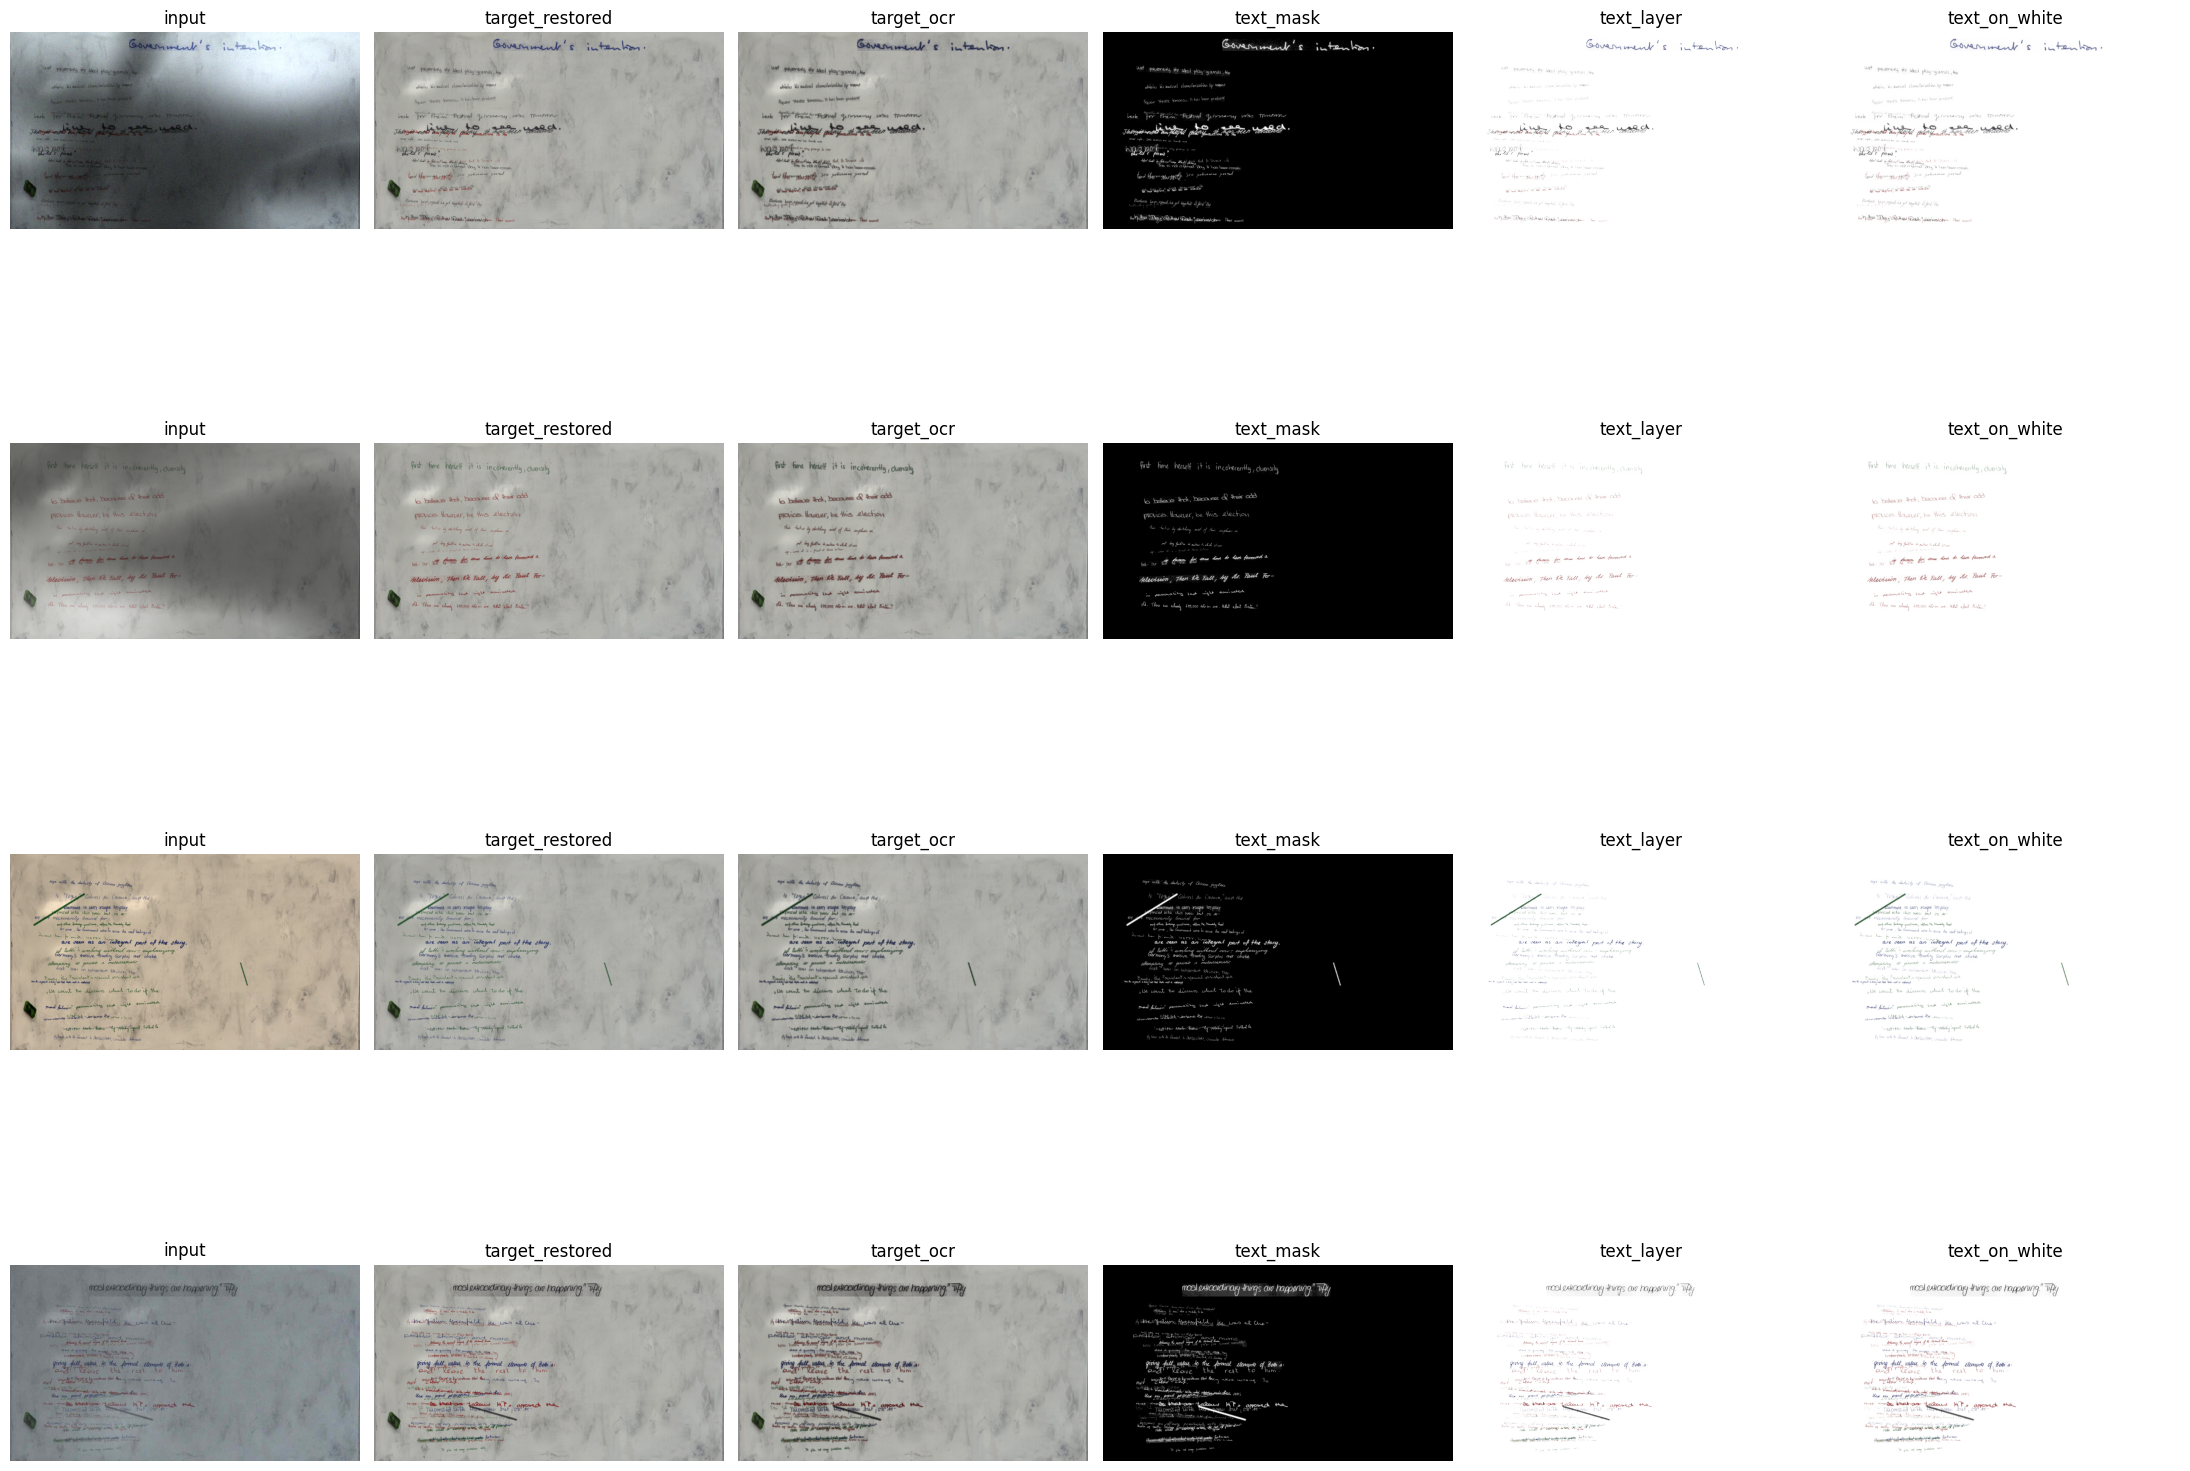


Dataset ZIP oluşturuluyor...
Local ZIP oluşturuldu: /content/generated_multihead_dataset_v2.zip
ZIP Drive'a kopyalanıyor...
Drive ZIP kaydedildi: /content/drive/MyDrive/Board2Notes/generated_multihead_dataset_v2.zip

Drive'a klasör kopyası yapılmadı.
Sebep: çok küçük dosya olduğu için Drive klasör kopyası yavaş olabilir.
Güvenli Drive yedeği ZIP olarak kaydedildi.

KULLANILACAK DATASET ROOT:
Bu oturumda eğitim için:
/content/generated_multihead_dataset_v2

Sonraki oturumlarda Drive ZIP'ten açmak için:
/content/drive/MyDrive/Board2Notes/generated_multihead_dataset_v2.zip


In [ ]:
# ============================================================
# Multi-head synthetic dataset üretimi - HIZLI LOCAL SÜRÜM
# BOARD_BACKGROUNDS + HW_ITEMS hazır olduktan sonra çalıştır
# ============================================================

from pathlib import Path
import os, json, math, random, shutil, time
import numpy as np
import cv2
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Dataset çıktı ayarları
# ------------------------------------------------------------

# ÖNEMLİ:
# Dataset önce local diske üretilecek. Bu çok daha hızlıdır.
CFG.GEN_DATASET_DIR_LOCAL = Path("/content/generated_multihead_dataset_v2")

# Drive tarafına ZIP olarak kaydedilecek.
CFG.GEN_DATASET_ZIP_DRIVE = Path("/content/drive/MyDrive/Board2Notes/generated_multihead_dataset_v2.zip")

# İstersen ayrıca Drive'a klasör olarak da kopyalayabilir.
# Çok dosya olduğu için yavaş olabilir. Şimdilik False kalsın.
COPY_FOLDER_TO_DRIVE = False
CFG.GEN_DATASET_DIR_DRIVE = Path("/content/drive/MyDrive/Board2Notes/generated_multihead_dataset_v2")

# Kod içinde kullanılacak aktif dataset path
CFG.GEN_DATASET_DIR = CFG.GEN_DATASET_DIR_LOCAL

# Eğitim için landscape board formatı
CFG.OUT_W = 1024
CFG.OUT_H = 576

# İlk ciddi üretim için ayarlar
CFG.PAIRS_PER_TRAIN_BOARD = 40
CFG.PAIRS_PER_VAL_BOARD   = 12
CFG.PAIRS_PER_TEST_BOARD  = 12

CFG.SPLIT_RATIOS = (0.80, 0.10, 0.10)
CFG.SEED = 42

# Eski datasetleri temizle
CLEAR_OLD_GENERATED = True

if CLEAR_OLD_GENERATED and CFG.GEN_DATASET_DIR_LOCAL.exists():
    print("Eski local generated dataset temizleniyor:", CFG.GEN_DATASET_DIR_LOCAL)
    shutil.rmtree(CFG.GEN_DATASET_DIR_LOCAL)

if CLEAR_OLD_GENERATED and CFG.GEN_DATASET_ZIP_DRIVE.exists():
    print("Eski Drive ZIP siliniyor:", CFG.GEN_DATASET_ZIP_DRIVE)
    CFG.GEN_DATASET_ZIP_DRIVE.unlink()

if CLEAR_OLD_GENERATED and COPY_FOLDER_TO_DRIVE and CFG.GEN_DATASET_DIR_DRIVE.exists():
    print("Eski Drive klasörü temizleniyor:", CFG.GEN_DATASET_DIR_DRIVE)
    shutil.rmtree(CFG.GEN_DATASET_DIR_DRIVE)

for split in ["train", "val", "test"]:
    for sub in ["input", "target_restored", "target_ocr", "text_mask", "text_layer", "text_on_white"]:
        (CFG.GEN_DATASET_DIR / split / sub).mkdir(parents=True, exist_ok=True)

print("Local dataset çıktı klasörü:", CFG.GEN_DATASET_DIR)
print("Drive ZIP hedefi:", CFG.GEN_DATASET_ZIP_DRIVE)
print("Drive klasör kopyası:", COPY_FOLDER_TO_DRIVE)

# ------------------------------------------------------------
# Kontroller
# ------------------------------------------------------------

assert "BOARD_BACKGROUNDS" in globals(), "BOARD_BACKGROUNDS yok. Önce board crop bloğunu çalıştır."
assert "HW_ITEMS" in globals(), "HW_ITEMS yok. Önce handwriting yükleme bloğunu çalıştır."

BOARD_BACKGROUNDS = list(BOARD_BACKGROUNDS)
assert len(BOARD_BACKGROUNDS) > 0, "BOARD_BACKGROUNDS boş."
assert len(HW_ITEMS) > 0, "HW_ITEMS boş."

print("Board background sayısı:", len(BOARD_BACKGROUNDS))
print("Handwriting parça sayısı:", len(HW_ITEMS))

# ------------------------------------------------------------
# Yardımcılar
# ------------------------------------------------------------

def read_rgb01(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise RuntimeError(f"Görüntü okunamadı: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32) / 255.0


def save_rgb(path, img01):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    arr = (np.clip(img01, 0, 1) * 255).astype(np.uint8)
    cv2.imwrite(
        str(path),
        cv2.cvtColor(arr, cv2.COLOR_RGB2BGR),
        [cv2.IMWRITE_PNG_COMPRESSION, 3]
    )


def save_gray(path, img01):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    arr = (np.clip(img01, 0, 1) * 255).astype(np.uint8)
    cv2.imwrite(str(path), arr, [cv2.IMWRITE_PNG_COMPRESSION, 3])


def save_rgba(path, rgb01, alpha01):
    """
    Pillow mode uyarısı vermeyen RGBA kaydetme fonksiyonu.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    rgb = (np.clip(rgb01, 0, 1) * 255).astype(np.uint8)
    a = (np.clip(alpha01, 0, 1) * 255).astype(np.uint8)
    rgba = np.dstack([rgb, a]).astype(np.uint8)

    Image.fromarray(rgba).save(path)


def resize_cover(img, out_h, out_w):
    h, w = img.shape[:2]
    scale = max(out_w / w, out_h / h)
    nw, nh = int(round(w * scale)), int(round(h * scale))

    im = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_CUBIC)

    y0 = max(0, (nh - out_h) // 2)
    x0 = max(0, (nw - out_w) // 2)

    return im[y0:y0 + out_h, x0:x0 + out_w].copy()


def normalize_board_background(img):
    """
    Boş tahta target'ını biraz daha temiz/flat hale getirir.
    Ama tamamen yapay beyaz yapmaz.
    """
    h, w = img.shape[:2]
    sigma = max(h, w) * 0.08

    blur = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma, sigmaY=sigma)
    mean = blur.mean(axis=(0, 1), keepdims=True)

    norm = img / (blur + 1e-4) * mean
    norm = np.clip(norm, 0, 1)

    out = 0.55 * img + 0.45 * norm
    return np.clip(out, 0, 1)


def get_hw_alpha(item):
    """
    HW_ITEMS hem dict hem ndarray olabilsin.
    """
    if isinstance(item, dict):
        a = item.get("alpha", None)
        if a is None:
            raise ValueError("HW item dict içinde alpha yok.")
        return a.astype(np.float32)

    return np.asarray(item, dtype=np.float32)


def augment_alpha(alpha, rng):
    a = alpha.copy().astype(np.float32)
    a = np.clip(a, 0, 1)

    # Hafif stroke varyasyonu
    k = np.ones((3, 3), np.uint8)
    r = rng.random()

    if r < 0.25:
        a = cv2.erode(a, k, iterations=1)
    elif r > 0.72:
        a = cv2.dilate(a, k, iterations=1)

    # Hafif rotasyon
    h, w = a.shape[:2]
    angle = rng.uniform(-3.5, 3.5)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)

    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    nw = int(w * cos + h * sin)
    nh = int(h * cos + w * sin)

    M[0, 2] += (nw - w) / 2
    M[1, 2] += (nh - h) / 2

    a = cv2.warpAffine(
        a,
        M,
        (max(1, nw), max(1, nh)),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    # Marker doğallığı: hafif yumuşatma
    if rng.random() < 0.65:
        a = cv2.GaussianBlur(a, (3, 3), 0)

    # Opacity varyasyonu
    a *= rng.uniform(0.68, 0.98)

    return np.clip(a, 0, 1)


MARKER_COLORS = np.array([
    [0.06, 0.06, 0.06],   # siyah
    [0.05, 0.08, 0.33],   # lacivert/mavi
    [0.45, 0.05, 0.05],   # kırmızı
    [0.04, 0.25, 0.08],   # yeşil
    [0.14, 0.14, 0.14],   # koyu gri
], dtype=np.float32)


def paste_alpha_text(canvas, mask, text_rgb_layer, alpha, x, y, color):
    h, w = alpha.shape[:2]
    H, W = mask.shape[:2]

    if x >= W or y >= H:
        return canvas, mask, text_rgb_layer

    x2 = min(W, x + w)
    y2 = min(H, y + h)

    if x2 <= x or y2 <= y:
        return canvas, mask, text_rgb_layer

    a = alpha[:y2 - y, :x2 - x]
    a3 = a[..., None]

    roi = canvas[y:y2, x:x2]
    col = color.reshape(1, 1, 3)

    # Tahta üzerine marker bindirme
    canvas[y:y2, x:x2] = roi * (1 - a3) + col * a3

    # Mask
    mask[y:y2, x:x2] = np.maximum(mask[y:y2, x:x2], a)

    # Text layer
    old = text_rgb_layer[y:y2, x:x2]
    text_rgb_layer[y:y2, x:x2] = old * (1 - a3) + col * a3

    return canvas, mask, text_rgb_layer


def compose_board_with_handwriting(board_bg, rng):
    """
    Gerçekçi tahta layout'u üretir:
    - sparse / medium / dense
    - satır hizalı yazılar
    - iki kolon ihtimali
    - başlık, not, çizgi/ok hissi
    """
    H, W = board_bg.shape[:2]

    canvas = board_bg.copy()
    text_mask = np.zeros((H, W), np.float32)
    text_rgb_layer = np.ones((H, W, 3), np.float32)

    layout_type = rng.choice(["sparse", "medium", "dense"], p=[0.25, 0.50, 0.25])

    if layout_type == "sparse":
        n_blocks = int(rng.integers(1, 3))
        lines_per_block = (3, 7)
        line_h_range = (22, 38)
    elif layout_type == "medium":
        n_blocks = int(rng.integers(2, 4))
        lines_per_block = (5, 10)
        line_h_range = (20, 34)
    else:
        n_blocks = int(rng.integers(3, 5))
        lines_per_block = (7, 14)
        line_h_range = (18, 30)

    margin_x = int(W * rng.uniform(0.05, 0.10))
    margin_y = int(H * rng.uniform(0.06, 0.12))

    use_two_cols = rng.random() < (0.35 if layout_type != "sparse" else 0.12)

    if use_two_cols:
        col_regions = [
            (margin_x, int(W * 0.48)),
            (int(W * 0.53), W - margin_x),
        ]
    else:
        col_regions = [(margin_x, W - margin_x)]

    # Başlık ihtimali
    if rng.random() < 0.65:
        hw = get_hw_alpha(HW_ITEMS[int(rng.integers(len(HW_ITEMS)))])
        hw = augment_alpha(hw, rng)

        target_h = int(rng.integers(28, 48))
        scale = target_h / max(1, hw.shape[0])

        new_w = int(hw.shape[1] * scale)
        new_h = int(hw.shape[0] * scale)

        if new_w > 30 and new_h > 12:
            hw = cv2.resize(hw, (new_w, new_h), interpolation=cv2.INTER_CUBIC)

            x = int(rng.integers(margin_x, max(margin_x + 1, W - margin_x - min(new_w, W // 2))))
            y = int(rng.integers(int(H * 0.03), int(H * 0.10)))

            color = MARKER_COLORS[int(rng.integers(len(MARKER_COLORS)))] + rng.normal(0, 0.025, 3)
            color = np.clip(color, 0, 1)

            canvas, text_mask, text_rgb_layer = paste_alpha_text(
                canvas, text_mask, text_rgb_layer, hw, x, y, color
            )

    # Yazı blokları
    for b in range(n_blocks):
        x1, x2 = col_regions[int(rng.integers(len(col_regions)))]
        block_w = x2 - x1

        if block_w < 100:
            continue

        y = int(rng.integers(margin_y, max(margin_y + 1, H - int(H * 0.22))))
        n_lines = int(rng.integers(lines_per_block[0], lines_per_block[1] + 1))
        line_gap = int(rng.integers(8, 18))

        color = MARKER_COLORS[int(rng.integers(len(MARKER_COLORS)))] + rng.normal(0, 0.025, 3)
        color = np.clip(color, 0, 1)

        for li in range(n_lines):
            if y >= H - margin_y:
                break

            hw = get_hw_alpha(HW_ITEMS[int(rng.integers(len(HW_ITEMS)))])
            hw = augment_alpha(hw, rng)

            target_h = int(rng.integers(line_h_range[0], line_h_range[1] + 1))
            scale = target_h / max(1, hw.shape[0])

            new_w = int(hw.shape[1] * scale)
            new_h = int(hw.shape[0] * scale)

            if new_w < 20 or new_h < 8:
                continue

            max_w = int(block_w * rng.uniform(0.45, 0.95))

            if new_w > max_w:
                scale2 = max_w / max(1, new_w)
                new_w = int(new_w * scale2)
                new_h = int(new_h * scale2)

            if new_w < 20 or new_h < 8:
                continue

            hw = cv2.resize(hw, (new_w, new_h), interpolation=cv2.INTER_CUBIC)

            jitter_x = int(rng.normal(0, 8))
            x = int(np.clip(
                x1 + rng.integers(0, max(1, int(block_w * 0.10))) + jitter_x,
                0,
                W - 1
            ))

            canvas, text_mask, text_rgb_layer = paste_alpha_text(
                canvas, text_mask, text_rgb_layer, hw, x, y, color
            )

            y += new_h + line_gap

    # Basit çizgi/ok/kutu ekleme ihtimali
    if rng.random() < 0.45:
        draw_mask = np.zeros((H, W), np.float32)
        color = MARKER_COLORS[int(rng.integers(len(MARKER_COLORS)))]

        for _ in range(int(rng.integers(1, 4))):
            x1 = int(rng.integers(margin_x, W - margin_x))
            y1 = int(rng.integers(margin_y, H - margin_y))
            x2 = int(np.clip(x1 + rng.integers(-180, 220), margin_x, W - margin_x))
            y2 = int(np.clip(y1 + rng.integers(-100, 120), margin_y, H - margin_y))

            thickness = int(rng.integers(2, 5))
            cv2.line(draw_mask, (x1, y1), (x2, y2), 1.0, thickness, cv2.LINE_AA)

        draw_mask = cv2.GaussianBlur(draw_mask, (3, 3), 0)
        a3 = draw_mask[..., None] * rng.uniform(0.65, 0.95)

        canvas = canvas * (1 - a3) + color.reshape(1, 1, 3) * a3
        text_rgb_layer = text_rgb_layer * (1 - a3) + color.reshape(1, 1, 3) * a3
        text_mask = np.maximum(text_mask, draw_mask)

    text_mask = np.clip(text_mask, 0, 1)

    return np.clip(canvas, 0, 1), text_mask, np.clip(text_rgb_layer, 0, 1)


def make_target_ocr(target_restored, text_mask):
    """
    OCR için yazıları hafif koyulaştırır/kalınlaştırır.
    Aşırı bloblaştırmamak için kontrollü.
    """
    m = text_mask.astype(np.float32)

    thick = cv2.dilate(
        (m > 0.25).astype(np.uint8),
        np.ones((3, 3), np.uint8),
        iterations=1
    ).astype(np.float32)

    soft = cv2.GaussianBlur(np.maximum(m, 0.55 * thick), (3, 3), 0)
    soft = np.clip(soft, 0, 1)

    out = target_restored.copy()
    out = out * (1 - soft[..., None] * 0.38)

    return np.clip(out, 0, 1), soft


# ------------------------------------------------------------
# Degradation motoru
# ------------------------------------------------------------

def odd(k):
    k = int(max(1, k))
    return k + 1 if k % 2 == 0 else k


def add_shadow(img, rng, strength=0.45):
    H, W = img.shape[:2]
    mask = np.zeros((H, W), np.float32)

    for _ in range(int(rng.integers(1, 4))):
        n = int(rng.integers(4, 8))
        pts = np.stack([
            rng.integers(-W // 3, W + W // 3, n),
            rng.integers(-H // 3, H + H // 3, n)
        ], axis=1).astype(np.int32)

        local = np.zeros((H, W), np.float32)
        cv2.fillPoly(local, [pts], 1.0)
        local = cv2.GaussianBlur(local, (0, 0), sigmaX=rng.uniform(35, 110))
        mask = np.maximum(mask, local)

    amount = rng.uniform(0.12, strength)
    return np.clip(img * (1 - mask[..., None] * amount), 0, 1)


def add_glare(img, rng, strength=0.55):
    H, W = img.shape[:2]
    yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)

    cx = rng.uniform(0, W)
    cy = rng.uniform(0, H)
    rx = rng.uniform(W * 0.08, W * 0.35)
    ry = rng.uniform(H * 0.05, H * 0.22)

    m = np.exp(-(((xx - cx) / rx) ** 2 + ((yy - cy) / ry) ** 2))
    m *= rng.uniform(0.18, strength)

    out = img + m[..., None] * (1 - img)
    return np.clip(out, 0, 1)


def add_gradient_light(img, rng):
    H, W = img.shape[:2]

    yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
    angle = rng.uniform(0, 2 * np.pi)

    g = np.cos(angle) * (xx / W) + np.sin(angle) * (yy / H)
    g = (g - g.min()) / (g.max() - g.min() + 1e-6)

    factor = rng.uniform(0.65, 0.95) + g * rng.uniform(0.08, 0.35)

    return np.clip(img * factor[..., None], 0, 1)


def add_blur(img, rng):
    if rng.random() < 0.5:
        k = odd(rng.integers(3, 9))
        return cv2.GaussianBlur(img, (k, k), 0)

    k = odd(rng.integers(5, 15))
    kernel = np.zeros((k, k), np.float32)
    cv2.line(kernel, (0, k // 2), (k - 1, k // 2), 1, 1)

    M = cv2.getRotationMatrix2D((k / 2, k / 2), rng.uniform(0, 180), 1)
    kernel = cv2.warpAffine(kernel, M, (k, k))
    kernel /= kernel.sum() + 1e-8

    return cv2.filter2D(img, -1, kernel)


def add_noise_jpeg(img, rng):
    out = img.copy()

    if rng.random() < 0.75:
        sigma = rng.uniform(0.005, 0.035)
        out = np.clip(out + rng.normal(0, sigma, out.shape).astype(np.float32), 0, 1)

    if rng.random() < 0.55:
        q = int(rng.integers(35, 92))
        arr = (np.clip(out, 0, 1) * 255).astype(np.uint8)

        ok, buf = cv2.imencode(
            ".jpg",
            cv2.cvtColor(arr, cv2.COLOR_RGB2BGR),
            [cv2.IMWRITE_JPEG_QUALITY, q]
        )

        if ok:
            dec = cv2.imdecode(buf, cv2.IMREAD_COLOR)
            out = cv2.cvtColor(dec, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    return np.clip(out, 0, 1)


def color_exposure(img, rng):
    out = img.copy()

    contrast = rng.uniform(0.72, 1.28)
    brightness = rng.uniform(-0.08, 0.10)

    out = (out - 0.5) * contrast + 0.5 + brightness

    shift = rng.uniform(-0.10, 0.10)
    out[..., 0] *= (1 + shift)
    out[..., 2] *= (1 - shift)

    return np.clip(out, 0, 1)


def degrade_image(clean, rng):
    out = clean.copy()

    difficulty = rng.choice(["easy", "medium", "hard"], p=[0.40, 0.45, 0.15])

    if difficulty == "easy":
        ops = int(rng.integers(1, 3))
        shadow_s = 0.32
        glare_s = 0.28
    elif difficulty == "medium":
        ops = int(rng.integers(3, 5))
        shadow_s = 0.50
        glare_s = 0.45
    else:
        ops = int(rng.integers(5, 7))
        shadow_s = 0.68
        glare_s = 0.65

    pool = ["shadow", "glare", "gradient", "blur", "noise_jpeg", "color"]
    rng.shuffle(pool)

    for op in pool[:ops]:
        if op == "shadow":
            out = add_shadow(out, rng, shadow_s)
        elif op == "glare":
            out = add_glare(out, rng, glare_s)
        elif op == "gradient":
            out = add_gradient_light(out, rng)
        elif op == "blur":
            out = add_blur(out, rng)
        elif op == "noise_jpeg":
            out = add_noise_jpeg(out, rng)
        elif op == "color":
            out = color_exposure(out, rng)

    return np.clip(out, 0, 1), difficulty


# ------------------------------------------------------------
# Board bazlı split
# ------------------------------------------------------------

rng = np.random.default_rng(CFG.SEED)

indices = np.arange(len(BOARD_BACKGROUNDS))
rng.shuffle(indices)

n = len(indices)
n_train = int(n * CFG.SPLIT_RATIOS[0])
n_val = int(n * CFG.SPLIT_RATIOS[1])

split_indices = {
    "train": indices[:n_train],
    "val": indices[n_train:n_train + n_val],
    "test": indices[n_train + n_val:],
}

print("Board split:")
for split, idxs in split_indices.items():
    print(split, len(idxs))

# ------------------------------------------------------------
# Dataset üret
# ------------------------------------------------------------

t_start = time.time()
metadata = []
global_id = 0

pairs_per_split = {
    "train": CFG.PAIRS_PER_TRAIN_BOARD,
    "val": CFG.PAIRS_PER_VAL_BOARD,
    "test": CFG.PAIRS_PER_TEST_BOARD,
}

for split, idxs in split_indices.items():
    pairs_per_board = pairs_per_split[split]

    print(f"\n{split} üretimi başlıyor | board={len(idxs)} | pairs_per_board={pairs_per_board}")

    for bi in tqdm(idxs, desc=f"generate {split}"):
        bg_path = Path(BOARD_BACKGROUNDS[int(bi)])

        bg = read_rgb01(bg_path)

        # Target background: landscape, normalize edilmiş tahta
        bg = resize_cover(bg, CFG.OUT_H, CFG.OUT_W)
        bg = normalize_board_background(bg)

        for k in range(pairs_per_board):
            local_seed = int(CFG.SEED + global_id * 17 + int(bi) * 31)
            rr = np.random.default_rng(local_seed)

            target_restored, text_mask, text_rgb_layer = compose_board_with_handwriting(bg, rr)
            target_ocr, ocr_mask = make_target_ocr(target_restored, text_mask)

            input_img, difficulty = degrade_image(target_restored, rr)

            alpha = np.clip(text_mask, 0, 1)

            white = np.ones_like(target_restored)
            text_on_white = white * (1 - alpha[..., None]) + text_rgb_layer * alpha[..., None]

            fn = f"{global_id:07d}.png"

            save_rgb(CFG.GEN_DATASET_DIR / split / "input" / fn, input_img)
            save_rgb(CFG.GEN_DATASET_DIR / split / "target_restored" / fn, target_restored)
            save_rgb(CFG.GEN_DATASET_DIR / split / "target_ocr" / fn, target_ocr)
            save_gray(CFG.GEN_DATASET_DIR / split / "text_mask" / fn, text_mask)
            save_rgba(CFG.GEN_DATASET_DIR / split / "text_layer" / fn, text_rgb_layer, alpha)
            save_rgb(CFG.GEN_DATASET_DIR / split / "text_on_white" / fn, text_on_white)

            metadata.append({
                "id": fn,
                "split": split,
                "background": bg_path.name,
                "difficulty": str(difficulty),
                "out_w": CFG.OUT_W,
                "out_h": CFG.OUT_H,
            })

            global_id += 1

# Metadata kaydet
with open(CFG.GEN_DATASET_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

elapsed = (time.time() - t_start) / 60

print("\nDataset üretimi tamamlandı.")
print("Toplam örnek:", len(metadata))
print(f"Süre: {elapsed:.1f} dk")
print("Local dataset klasörü:", CFG.GEN_DATASET_DIR)

# ------------------------------------------------------------
# Sayım
# ------------------------------------------------------------

for split in ["train", "val", "test"]:
    count = len(list((CFG.GEN_DATASET_DIR / split / "input").glob("*.png")))
    print(split, "input sayısı:", count)

# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

preview_split = "train"
preview_files = sorted((CFG.GEN_DATASET_DIR / preview_split / "input").glob("*.png"))[:4]

cols = 6
rows = len(preview_files)

plt.figure(figsize=(22, 4.5 * rows))

subdirs = ["input", "target_restored", "target_ocr", "text_mask", "text_layer", "text_on_white"]

for r, p in enumerate(preview_files):
    fn = p.name

    for c, sub in enumerate(subdirs):
        pp = CFG.GEN_DATASET_DIR / preview_split / sub / fn

        if sub == "text_layer":
            im = Image.open(pp).convert("RGBA")
        elif sub == "text_mask":
            im = Image.open(pp).convert("L")
        else:
            im = Image.open(pp).convert("RGB")

        plt.subplot(rows, cols, r * cols + c + 1)

        if sub == "text_mask":
            plt.imshow(im, cmap="gray")
        else:
            plt.imshow(im)

        plt.title(sub)
        plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Local dataset'i ZIP yap ve Drive'a kaydet
# ------------------------------------------------------------

print("\nDataset ZIP oluşturuluyor...")

zip_base_local = Path("/content/generated_multihead_dataset_v2")
zip_file_local = Path(str(zip_base_local) + ".zip")

if zip_file_local.exists():
    zip_file_local.unlink()

# make_archive dosya uzantısını kendi ekler
shutil.make_archive(
    base_name=str(zip_base_local),
    format="zip",
    root_dir=str(CFG.GEN_DATASET_DIR.parent),
    base_dir=str(CFG.GEN_DATASET_DIR.name)
)

print("Local ZIP oluşturuldu:", zip_file_local)

CFG.GEN_DATASET_ZIP_DRIVE.parent.mkdir(parents=True, exist_ok=True)

if CFG.GEN_DATASET_ZIP_DRIVE.exists():
    CFG.GEN_DATASET_ZIP_DRIVE.unlink()

print("ZIP Drive'a kopyalanıyor...")
shutil.copy2(zip_file_local, CFG.GEN_DATASET_ZIP_DRIVE)

print("Drive ZIP kaydedildi:", CFG.GEN_DATASET_ZIP_DRIVE)

# ------------------------------------------------------------
# İsteğe bağlı: klasör olarak Drive'a kopyala
# ------------------------------------------------------------

if COPY_FOLDER_TO_DRIVE:
    print("\nDataset klasör olarak Drive'a kopyalanıyor...")
    print("Kaynak:", CFG.GEN_DATASET_DIR_LOCAL)
    print("Hedef :", CFG.GEN_DATASET_DIR_DRIVE)

    if CFG.GEN_DATASET_DIR_DRIVE.exists():
        shutil.rmtree(CFG.GEN_DATASET_DIR_DRIVE)

    shutil.copytree(CFG.GEN_DATASET_DIR_LOCAL, CFG.GEN_DATASET_DIR_DRIVE)

    print("Drive klasör kopyalama tamamlandı:", CFG.GEN_DATASET_DIR_DRIVE)
else:
    print("\nDrive'a klasör kopyası yapılmadı.")
    print("Sebep: çok küçük dosya olduğu için Drive klasör kopyası yavaş olabilir.")
    print("Güvenli Drive yedeği ZIP olarak kaydedildi.")

print("\nKULLANILACAK DATASET ROOT:")
print("Bu oturumda eğitim için:")
print(CFG.GEN_DATASET_DIR_LOCAL)

print("\nSonraki oturumlarda Drive ZIP'ten açmak için:")
print(CFG.GEN_DATASET_ZIP_DRIVE)

In [ ]:
# ============================================================
# MODEL 2 ONNX EXPORT - GEREKLİ PAKETLER
# ============================================================

import sys, subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "onnx",
    "onnxscript",
    "onnxruntime"
])

print("ONNX paketleri hazır.")

ONNX paketleri hazır.


In [ ]:
# ============================================================
# BOARD2NOTES MODEL 2 - ONNX EXPORT + DRIVE KAYIT + BİLGİSAYARA İNDİRME
# Enhancement / OCR-ready / Text-mask multi-head export
# ============================================================

from pathlib import Path
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from google.colab import files

# ------------------------------------------------------------
# 1) Drive mount
# ------------------------------------------------------------

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception as e:
    print("Drive mount kontrolü:", repr(e))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 512  # Model 2 eğitiminde ana enhancement boyutu olarak 512 kullanıldıysa doğru seçim.

# ------------------------------------------------------------
# 2) Checkpoint yolu
# Önce bilinen final_model.pt yolu denenir.
# Bulunamazsa Drive içinde aday arar.
# ------------------------------------------------------------

KNOWN_CKPT = Path("/content/drive/MyDrive/Board2Notes/runs_nafnet_base_multihead/nafnet_base64_multihead_v2_optimized/final_model.pt")

candidate_patterns = [
    "/content/drive/MyDrive/Board2Notes/**/final_model.pt",
    "/content/drive/MyDrive/Board2Notes/**/best.pt",
    "/content/drive/MyDrive/Board2Notes/**/*multihead*.pt",
    "/content/drive/MyDrive/Board2Notes/**/*nafnet*.pt",
]

if KNOWN_CKPT.exists():
    CKPT_PATH = KNOWN_CKPT
else:
    candidates = []
    for pat in candidate_patterns:
        candidates.extend(Path("/").glob(pat.lstrip("/")))

    candidates = sorted(
        [p for p in candidates if p.exists()],
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )

    print("Bulunan checkpoint adayları:")
    for i, p in enumerate(candidates[:20]):
        print(f"{i:02d} | {p} | MB={p.stat().st_size / 1024 / 1024:.2f}")

    assert candidates, "Model 2 checkpoint bulunamadı. CKPT_PATH'i manuel gir."
    CKPT_PATH = candidates[0]

print("\nKullanılacak checkpoint:")
print(CKPT_PATH)
print("Checkpoint MB:", round(CKPT_PATH.stat().st_size / 1024 / 1024, 2))

# ------------------------------------------------------------
# 3) Çıktı yolları
# ------------------------------------------------------------

OUT_LOCAL_DIR = Path("/content/model2_onnx_export")
OUT_LOCAL_DIR.mkdir(parents=True, exist_ok=True)

OUT_DRIVE_DIR = Path("/content/drive/MyDrive/Board2Notes/models/model2_enhancement")
OUT_DRIVE_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_ONNX = OUT_LOCAL_DIR / "board2notes_model2_enhancement_512_full.onnx"
DRIVE_ONNX = OUT_DRIVE_DIR / "board2notes_model2_enhancement_512_full.onnx"

LOCAL_PT_COPY = OUT_LOCAL_DIR / "board2notes_model2_final_source.pt"
DRIVE_PT_COPY = OUT_DRIVE_DIR / "board2notes_model2_final_source.pt"

# ------------------------------------------------------------
# 4) Checkpoint yükleme
# ------------------------------------------------------------

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)

print("\nCheckpoint type:", type(ckpt))
if isinstance(ckpt, dict):
    print("Checkpoint keys:", list(ckpt.keys()))

# ------------------------------------------------------------
# 5) State_dict çıkarma
# Desteklenen formatlar:
# - {"ema": ...}
# - {"model": ...}
# - {"state_dict": ...}
# - {"G_ema": ...} / {"G": ...} pix2pix generator
# - direkt state_dict
# ------------------------------------------------------------

def extract_state_dict(ckpt):
    if isinstance(ckpt, dict):
        for key in ["ema", "model", "state_dict", "G_ema", "G", "generator"]:
            if key in ckpt and ckpt[key] is not None:
                print("State dict key seçildi:", key)
                return ckpt[key], key

        # Direkt state_dict olabilir
        if all(torch.is_tensor(v) for v in ckpt.values()):
            print("Checkpoint direkt state_dict gibi görünüyor.")
            return ckpt, "direct"

    raise RuntimeError("Checkpoint içinden model state_dict çıkarılamadı.")

state_dict, state_key = extract_state_dict(ckpt)

# Prefix temizliği
clean_state = {}
for k, v in state_dict.items():
    nk = str(k)
    for pref in ["module.", "_orig_mod."]:
        if nk.startswith(pref):
            nk = nk[len(pref):]
    clean_state[nk] = v

state_dict = clean_state

# ------------------------------------------------------------
# 6) Model mimarisini oluşturma
# ÖNEMLİ:
# Bu hücreyi 2. model eğitim notebook'unda çalıştır.
# build_model veya make_models tanımlı olmalı.
# ------------------------------------------------------------

def create_model2():
    # Multi-head NAFNet tarzı notebooklarda genelde build_model vardır.
    if "build_model" in globals():
        print("build_model bulundu, Model 2 bununla oluşturulacak.")

        # Farklı imzaları güvenli dene
        trials = [
            lambda: build_model(),
            lambda: build_model(3),
            lambda: build_model(num_classes=3),
            lambda: build_model(CFG),
        ]

        last_err = None
        for fn in trials:
            try:
                m = fn()
                print("build_model ile model oluşturuldu.")
                return m
            except Exception as e:
                last_err = e

        raise RuntimeError(f"build_model var ama çağrı başarısız: {repr(last_err)}")

    # Pix2pix/GAN eğitim kodunda make_models olabilir. Checkpoint G/G_ema ise generator export edilir.
    if "make_models" in globals():
        print("make_models bulundu, generator modeli oluşturulacak.")
        result = make_models(DEVICE)

        if isinstance(result, tuple):
            G = result[0]
        else:
            G = result

        return G

    raise RuntimeError(
        "Model mimarisi bulunamadı. Önce 2. model eğitim notebook'undaki "
        "model tanımlama hücrelerini çalıştır. build_model veya make_models tanımlı olmalı."
    )

model2 = create_model2()
model2 = model2.to(DEVICE)

missing, unexpected = model2.load_state_dict(
    {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in state_dict.items()},
    strict=False
)

print("\nload_state_dict raporu:")
print("missing keys   :", len(missing))
print("unexpected keys:", len(unexpected))

if len(unexpected) > 0:
    print("İlk unexpected keys:", unexpected[:20])

if len(missing) > 0:
    print("İlk missing keys:", missing[:20])

# Eğer çok fazla key uyuşmadıysa yanlış model mimarisi yüklenmiş olabilir.
total_state_keys = len(state_dict)
bad_ratio = (len(missing) + len(unexpected)) / max(1, total_state_keys)

if len(unexpected) > total_state_keys * 0.30:
    raise RuntimeError(
        "Checkpoint ile model mimarisi uyuşmuyor gibi görünüyor. "
        "Büyük ihtimalle bu runtime'daki build_model Model 1'e ait veya yanlış notebooktasın. "
        "2. model eğitim notebook'unda model mimari hücrelerini çalıştırıp tekrar dene."
    )

model2.eval()
print("\nModel 2 yüklendi.")

# ------------------------------------------------------------
# 7) Multi-head ONNX wrapper
# Her durumda 3 çıktı üretir:
#   restored
#   ocr_enhanced
#   text_mask_logits
# ------------------------------------------------------------

class Board2NotesModel2OnnxWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def _from_dict(self, out, keys):
        for k in keys:
            if k in out:
                return out[k]
        return None

    def forward(self, x):
        out = self.model(x)

        restored = None
        ocr = None
        mask = None

        if isinstance(out, dict):
            restored = self._from_dict(out, [
                "restored", "restore", "pred_restored", "out_restored",
                "clean", "enhanced", "image", "out"
            ])

            ocr = self._from_dict(out, [
                "ocr", "ocr_enhanced", "pred_ocr", "out_ocr",
                "readable", "text_enhanced"
            ])

            mask = self._from_dict(out, [
                "mask", "text_mask", "mask_logits", "pred_mask",
                "out_mask", "writing_mask"
            ])

        elif isinstance(out, (tuple, list)):
            if len(out) >= 1:
                restored = out[0]
            if len(out) >= 2:
                ocr = out[1]
            if len(out) >= 3:
                mask = out[2]

        else:
            restored = out

        # Eksik head varsa fallback
        if restored is None:
            restored = x

        if ocr is None:
            ocr = restored

        if mask is None:
            mask = torch.zeros(
                (x.shape[0], 1, restored.shape[-2], restored.shape[-1]),
                device=restored.device,
                dtype=restored.dtype
            )

        # Mask kanalı 1 değilse ilk kanalı al
        if mask.dim() == 4 and mask.shape[1] != 1:
            mask = mask[:, :1, :, :]

        # Boyutları input ile aynı yap
        if restored.shape[-2:] != x.shape[-2:]:
            restored = F.interpolate(
                restored,
                size=x.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        if ocr.shape[-2:] != x.shape[-2:]:
            ocr = F.interpolate(
                ocr,
                size=x.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        if mask.shape[-2:] != x.shape[-2:]:
            mask = F.interpolate(
                mask,
                size=x.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        return restored, ocr, mask

export_model = Board2NotesModel2OnnxWrapper(model2).to(DEVICE).eval()

# ------------------------------------------------------------
# 8) Export öncesi test
# ------------------------------------------------------------

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

with torch.no_grad():
    y_restored, y_ocr, y_mask = export_model(dummy)

print("\nExport test output shapes:")
print("restored       :", tuple(y_restored.shape))
print("ocr_enhanced   :", tuple(y_ocr.shape))
print("text_mask_logits:", tuple(y_mask.shape))

# ------------------------------------------------------------
# 9) ONNX export
# Legacy exporter daha stabil.
# Kotlin/Android için sabit 1x3x512x512 daha güvenli.
# ------------------------------------------------------------

torch.onnx.export(
    export_model,
    dummy,
    str(LOCAL_ONNX),
    export_params=True,
    input_names=["input"],
    output_names=["restored", "ocr_enhanced", "text_mask_logits"],
    opset_version=18,
    do_constant_folding=True,
    keep_initializers_as_inputs=False,
    dynamic_axes=None,
    dynamo=False,
)

print("\nONNX export tamamlandı:")
print(LOCAL_ONNX)
print("Local ONNX MB:", round(LOCAL_ONNX.stat().st_size / 1024 / 1024, 3))

# ------------------------------------------------------------
# 10) Drive'a kopyala
# ------------------------------------------------------------

shutil.copy2(LOCAL_ONNX, DRIVE_ONNX)
shutil.copy2(CKPT_PATH, DRIVE_PT_COPY)
shutil.copy2(CKPT_PATH, LOCAL_PT_COPY)

print("\nDrive kayıtları:")
print("ONNX:", DRIVE_ONNX)
print("PT  :", DRIVE_PT_COPY)
print("ONNX MB:", round(DRIVE_ONNX.stat().st_size / 1024 / 1024, 3))

# ------------------------------------------------------------
# 11) Bilgisayara indir
# ------------------------------------------------------------

print("\nBilgisayara indiriliyor...")
files.download(str(DRIVE_ONNX))

print("\nİşlem tamamlandı.")

Mounted at /content/drive

Kullanılacak checkpoint:
/content/drive/MyDrive/Board2Notes/runs_nafnet_base_multihead/nafnet_base64_multihead_v2_optimized/final_model.pt
Checkpoint MB: 442.72

Checkpoint type: <class 'dict'>
Checkpoint keys: ['model', 'cfg', 'test_metrics']
State dict key seçildi: model


RuntimeError: Model mimarisi bulunamadı. Önce 2. model eğitim notebook'undaki model tanımlama hücrelerini çalıştır. build_model veya make_models tanımlı olmalı.